# 03: Exploratory Analysis

## Goal
Understand how the share of ICU beds in use behaves before building any forecasts. Each question below is tied to a decision the forecasting models depend on.

| # | Question | Decision it informs |
|---|---|---|
| 1 | Does the share follow a yearly pattern? | Whether the model needs to know the time of year |
| 2 | Has the normal level shifted over the years? | Which years to train on |
| 3 | How much does the share move over 1 to 4 weeks? | How hard each forecast horizon is, and how strong the simple baseline will be |
| 4 | What drives the winter rise? | Whether respiratory illness data is worth adding to the model |
| 5 | Do hospital admissions rise before ICU occupancy? | Whether admissions can serve as an early warning signal |
| 6 | How stable is the number of ICU beds? | How to convert a forecast share back into a number of beds |

## Data
- The cleaned weekly series from Notebook 02 (`data/processed/icu_weekly_california.csv`), with the share of ICU beds in use and a flag for the 2024 voluntary reporting weeks.
- For questions 4 and 5, respiratory illness counts (COVID-19, flu, RSV) are pulled from the raw file. They will move into the cleaning notebook if they end up as model inputs.

Flagged 2024 weeks are left out of averages and correlations throughout, since their values run about 2 points low.

In [9]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

processed_file_path = Path("../data/processed/icu_weekly_california.csv")
icu_weekly = pd.read_csv(processed_file_path, parse_dates=["week_ending"])

icu_weekly["year"] = icu_weekly["week_ending"].dt.year
icu_weekly["month"] = icu_weekly["week_ending"].dt.month
# Weeks counted from January 1 of each year, so every year lines up on the same calendar
icu_weekly["week_of_year"] = (icu_weekly["week_ending"].dt.dayofyear - 1) // 7 + 1

raw_file_path = sorted(Path("../data/raw").glob("nhsn_hrd_california_weekly_*.csv"))[-1]
respiratory_columns = {
    "totalconfc19icupats": "covid_icu_patients",
    "totalconffluicupats": "flu_icu_patients",
    "totalconfrsvicupats": "rsv_icu_patients",
    "totalconfc19newadm": "covid_new_admissions",
    "totalconfflunewadm": "flu_new_admissions",
    "totalconfrsvnewadm": "rsv_new_admissions",
}
respiratory_weekly = pd.read_csv(raw_file_path, usecols=["weekendingdate", *respiratory_columns])
respiratory_weekly = respiratory_weekly.rename(columns=respiratory_columns)
respiratory_weekly["week_ending"] = pd.to_datetime(respiratory_weekly["weekendingdate"]).dt.normalize()
respiratory_weekly = respiratory_weekly.drop(columns="weekendingdate")

icu_weekly = icu_weekly.merge(respiratory_weekly, on="week_ending", how="left")
reliable_weeks = icu_weekly[~icu_weekly["is_voluntary_reporting_week"]]
complete_years = [2021, 2022, 2023, 2024, 2025]
month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

print("Rows, columns:", icu_weekly.shape)
print("Weeks per year:")
print(icu_weekly["year"].value_counts().sort_index().to_string())
print()
print("First week each respiratory measure was reported:")
for column_name in respiratory_columns.values():
    first_reported = icu_weekly.loc[icu_weekly[column_name].notna(), "week_ending"].min()
    print(f"  {column_name}: {first_reported.date()}")

Rows, columns: (321, 15)
Weeks per year:
year
2020    21
2021    52
2022    53
2023    52
2024    52
2025    52
2026    39

First week each respiratory measure was reported:
  covid_icu_patients: 2020-08-08
  flu_icu_patients: 2020-10-17
  rsv_icu_patients: 2023-11-25
  covid_new_admissions: 2020-08-08
  flu_new_admissions: 2020-10-17
  rsv_new_admissions: 2023-11-25


## Question 1: Does the share follow a yearly pattern?
Respiratory illnesses like flu, COVID-19, and RSV usually rise in winter. If the share of ICU beds in use rises at the same time each year, a forecast must account for it, or it will be caught off guard by every winter surge.

**Method:** overlay each full year (2021 to 2025) on the same January-to-December calendar, so the same weeks line up. Then compare the average share by month, with each year's monthly value shown so the spread between years is visible. 2020 and 2026 are partial years and are left out so every month is compared on equal terms.

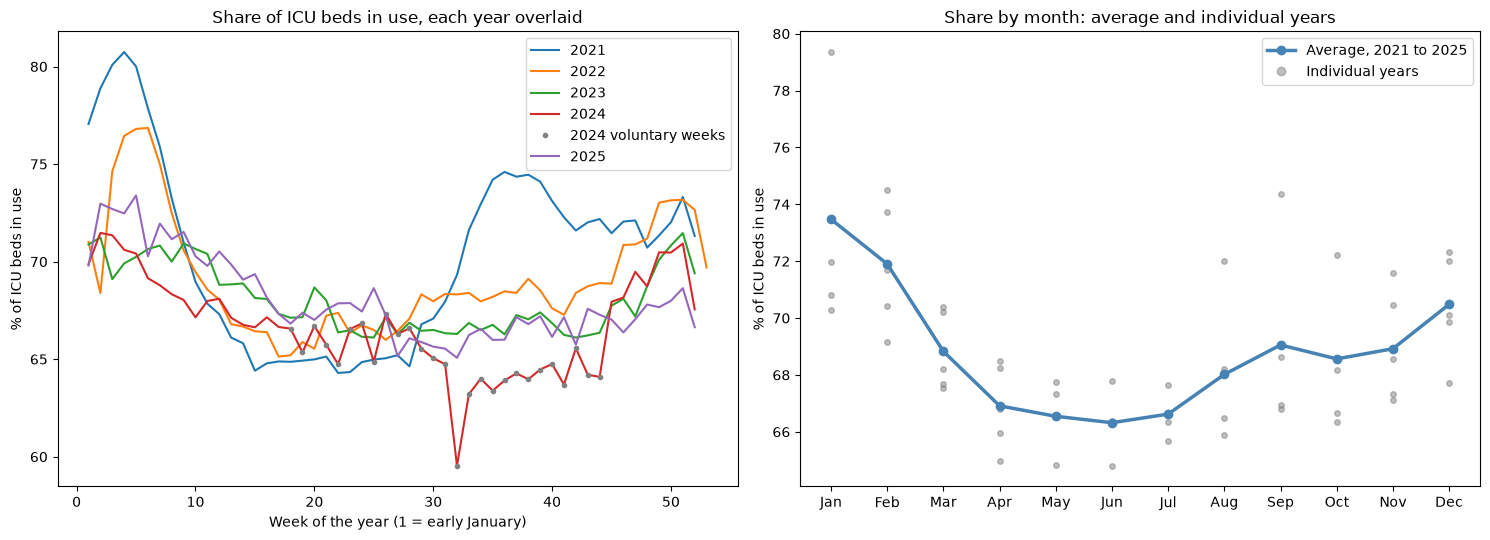

Monthly share by year (%):
year   2021  2022  2023  2024  2025
month                              
1      79.4  73.5  70.3  70.8  72.0
2      74.5  73.7  70.4  69.2  71.7
3      67.6  68.2  70.2  67.7  70.4
4      65.0  66.0  68.3  66.8  68.5
5      64.8  66.5  67.7   NaN  67.3
6      64.8  66.4  66.3   NaN  67.8
7      66.3  67.6  66.6   NaN  65.7
8      72.0  68.2  66.5   NaN  65.9
9      74.4  68.6  66.9   NaN  66.8
10     72.2  68.2  66.4   NaN  66.7
11     71.6  70.4  67.3  68.6  67.1
12     72.0  72.3  70.1  69.9  67.7

Highest week each year:
  2021: 80.7% (week ending 2021-01-23)
  2022: 76.9% (week ending 2022-02-05)
  2023: 71.5% (week ending 2023-12-23)
  2024: 71.5% (week ending 2024-01-13)
  2025: 73.4% (week ending 2025-02-01)


In [10]:
figure, (yearly_axis, monthly_axis) = plt.subplots(1, 2, figsize=(15, 5.5))

for year in complete_years:
    year_weeks = icu_weekly[icu_weekly["year"] == year]
    yearly_axis.plot(year_weeks["week_of_year"], year_weeks["icu_occupancy_share_pct"], label=str(year), linewidth=1.5)
    flagged_weeks = year_weeks[year_weeks["is_voluntary_reporting_week"]]
    if not flagged_weeks.empty:
        yearly_axis.plot(
            flagged_weeks["week_of_year"], flagged_weeks["icu_occupancy_share_pct"],
            linestyle="none", marker="o", markersize=3, color="gray", label="2024 voluntary weeks",
        )
yearly_axis.set_xlabel("Week of the year (1 = early January)")
yearly_axis.set_ylabel("% of ICU beds in use")
yearly_axis.set_title("Share of ICU beds in use, each year overlaid")
yearly_axis.legend()

reliable_full_years = reliable_weeks[reliable_weeks["year"].isin(complete_years)]
share_by_year_and_month = reliable_full_years.pivot_table(
    index="month", columns="year", values="icu_occupancy_share_pct", aggfunc="mean"
)
monthly_average_share = reliable_full_years.groupby("month")["icu_occupancy_share_pct"].mean()

# Dots and lines are read by position, not height, so the axis does not need to start at zero
for year in complete_years:
    monthly_axis.plot(
        share_by_year_and_month.index, share_by_year_and_month[year],
        linestyle="none", marker="o", markersize=4, color="gray", alpha=0.5,
    )
monthly_axis.plot(
    monthly_average_share.index, monthly_average_share.values,
    marker="o", color="steelblue", linewidth=2.5, label="Average, 2021 to 2025",
)
monthly_axis.plot([], [], linestyle="none", marker="o", color="gray", alpha=0.5, label="Individual years")
monthly_axis.set_xticks(range(1, 13))
monthly_axis.set_xticklabels(month_labels)
monthly_axis.set_ylabel("% of ICU beds in use")
monthly_axis.set_title("Share by month: average and individual years")
monthly_axis.legend()

plt.tight_layout()
plt.show()

print("Monthly share by year (%):")
print(share_by_year_and_month.round(1).to_string())
print()
print("Highest week each year:")
for year in complete_years:
    year_weeks = reliable_weeks[reliable_weeks["year"] == year]
    peak_row = year_weeks.loc[year_weeks["icu_occupancy_share_pct"].idxmax()]
    print(f"  {year}: {peak_row['icu_occupancy_share_pct']:.1f}% (week ending {peak_row['week_ending'].date()})")

### Finding: the share rises every winter, but the size and timing of the peak vary

**Result**
- Across 2021 to 2025, the share of ICU beds in use averaged 73.5% in January and about 66.5% from May to July, a gap of about 7 points. On roughly 10,000 ICU beds, that is about 700 more patients in an average January than an average June.
- Every year follows the same shape: highest in winter, lowest in late spring and summer.
- The winter peak has shrunk since 2021: 80.7% in 2021, 76.9% in 2022, 71.5% in 2023 and 2024, and 73.4% in 2025.
- The peak week varies, from late December (2023) to early February (2022 and 2025).
- 2021 also shows a second rise in August and September, up to about 74%, not seen in other years.

**Interpretation**
A forecast must account for the yearly pattern, or it will miss every winter rise. But the pattern alone is not enough: because the peak's size and timing change from year to year, a model also needs to respond to what recent weeks show. The 7-point average gap is partly driven by the large peaks of 2021 and 2022, so recent years swing less than the average suggests.

**Limitation**
Only five full years of data are available, and two of them include unusual COVID-19 waves. That is a small number of winters to learn the pattern from, so estimates of a "typical" winter peak carry real uncertainty. The cause of the 2021 late-summer rise has not been checked yet.

## Question 2: Has the normal level shifted over the years?
Question 1 showed the winter peaks shrinking after 2021 and 2022. If the typical level of the share has also changed, the COVID-19 years may teach a model patterns that no longer apply. This decides which years to train on.

**Method:** a 52-week rolling average, meaning the average share over the previous full year at each point in time. Because it always covers exactly one year, every season is included once, so the yearly pattern cancels out and only the longer-term level remains. A summary for each year compares the level and the size of its swings.

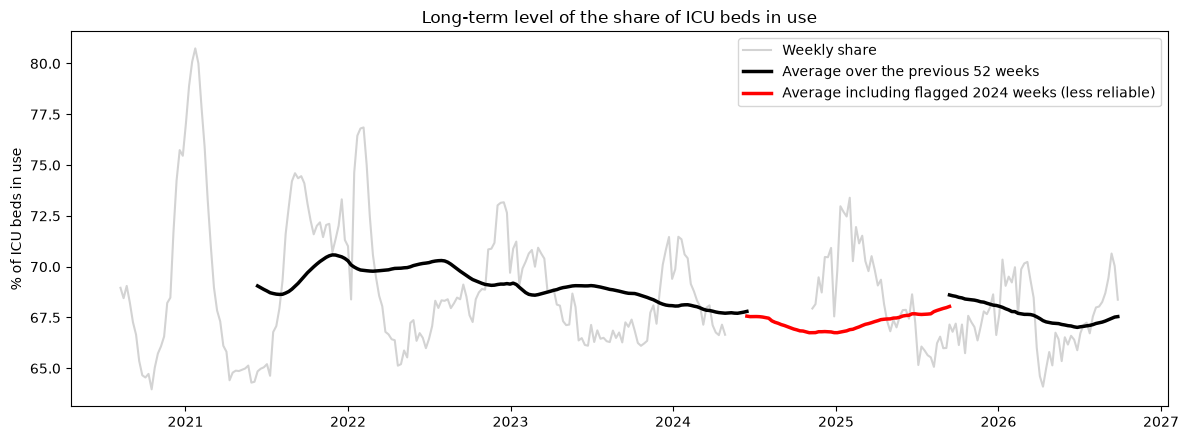

Share of ICU beds in use by year (%), excluding flagged weeks:
      average  lowest  highest  typical_weekly_spread  highest_minus_lowest
year                                                                       
2021     70.4    64.3     80.7                    4.8                  16.4
2022     69.2    65.1     76.9                    3.0                  11.8
2023     68.1    66.1     71.5                    1.7                   5.4
2024     68.8    66.6     71.5                    1.6                   4.9
2025     68.1    65.1     73.4                    2.2                   8.3


In [11]:
level_series = icu_weekly.set_index("week_ending")["icu_occupancy_share_pct"].copy()
level_series[icu_weekly.set_index("week_ending")["is_voluntary_reporting_week"]] = np.nan
rolling_one_year_average = level_series.rolling(window=52, min_periods=45).mean()

figure, level_axis = plt.subplots(figsize=(12, 4.5))
level_axis.plot(level_series.index, level_series, color="lightgray", label="Weekly share")
level_axis.plot(rolling_one_year_average.index, rolling_one_year_average, color="black", linewidth=2.5, label="Average over the previous 52 weeks")
# In the gap, show the same 52-week average calculated with the flagged weeks included.
# It is drawn in red because those weeks run about 2 points low, so this part is less reliable.
rolling_average_all_weeks = (
    icu_weekly.set_index("week_ending")["icu_occupancy_share_pct"].rolling(window=52, min_periods=45).mean()
)
first_reliable_week = rolling_one_year_average.first_valid_index()
in_gap = rolling_one_year_average.isna() & (rolling_average_all_weeks.index > first_reliable_week)
# Extend the red section one week on each side so it joins the black line
in_gap = in_gap | in_gap.shift(1, fill_value=False) | in_gap.shift(-1, fill_value=False)
level_axis.plot(
    rolling_average_all_weeks.index,
    rolling_average_all_weeks.where(in_gap),
    color="red", linewidth=2.5,
    label="Average including flagged 2024 weeks (less reliable)",
)
level_axis.set_ylabel("% of ICU beds in use")
level_axis.set_title("Long-term level of the share of ICU beds in use")
level_axis.legend()
plt.tight_layout()
plt.show()

yearly_summary = (
    reliable_weeks[reliable_weeks["year"].isin(complete_years)]
    .groupby("year")["icu_occupancy_share_pct"]
    .agg(average="mean", lowest="min", highest="max", typical_weekly_spread="std")
    .round(1)
)
yearly_summary["highest_minus_lowest"] = (yearly_summary["highest"] - yearly_summary["lowest"]).round(1)
print("Share of ICU beds in use by year (%), excluding flagged weeks:")
print(yearly_summary.to_string())

### Finding: the level settled near 68%, but the size of the swings changed a lot

**Result**
- The yearly average fell from 70.4% in 2021 to 68.1% in 2023, then stayed close to 68% through 2025 (68.8% in 2024, 68.1% in 2025). The 52-week average shows the same: a gradual decline through 2023, then a flat level.
- The gap between each year's highest and lowest week shrank from 16.4 points in 2021 and 11.8 in 2022 to about 5 points in 2023 and 2024, then rose to 8.3 in 2025.

**Interpretation**
The long-term level changed by about 2 points, small next to the 7-point seasonal swing, and has been stable since 2023. What changed more is how far the share moves within a year. 2021 and 2022 had much larger swings than any year since. A model trained on them may expect bigger swings than recent years show. A model trained without them would see only 3 to 4 winters and no large surge, so its forecast ranges could be too narrow if a large surge happens again.

**Decision**
Rather than dropping 2021 and 2022 by assumption, the models will be trained both with and without them, and compared on how well they forecast recent weeks.

**Limitation**
The 52-week average from mid-2024 to September 2025 includes the flagged voluntary weeks (shown in red), so the level in that window is slightly understated.

## Question 3: How much does the share move over 1 to 4 weeks?
The forecast looks 1 to 4 weeks ahead. How much the share typically changes over those spans sets how hard each horizon is. It also explains how strong the simplest baseline, "the share will stay the same as this week," should be: if the share rarely moves much in a week, that rule will be hard to beat.

**Method:** for each week, measure how much the share changed compared with 1, 2, 3, and 4 weeks earlier. The typical size of those changes is exactly the error the "stay the same" rule would make. Changes are only measured between weeks where neither is flagged.

How much the share changes over 1 to 4 weeks (percentage points):
             comparisons  avg_size_of_change  middle_80pct_low  middle_80pct_high  largest_rise  largest_drop
weeks_ahead                                                                                                  
1                    292                0.81             -1.26               1.29          6.24         -3.37
2                    290                1.19             -1.77               1.86          8.06         -4.91
3                    288                1.52             -2.26               2.31          8.41         -6.93
4                    286                1.79             -2.71               2.61          8.47         -9.02


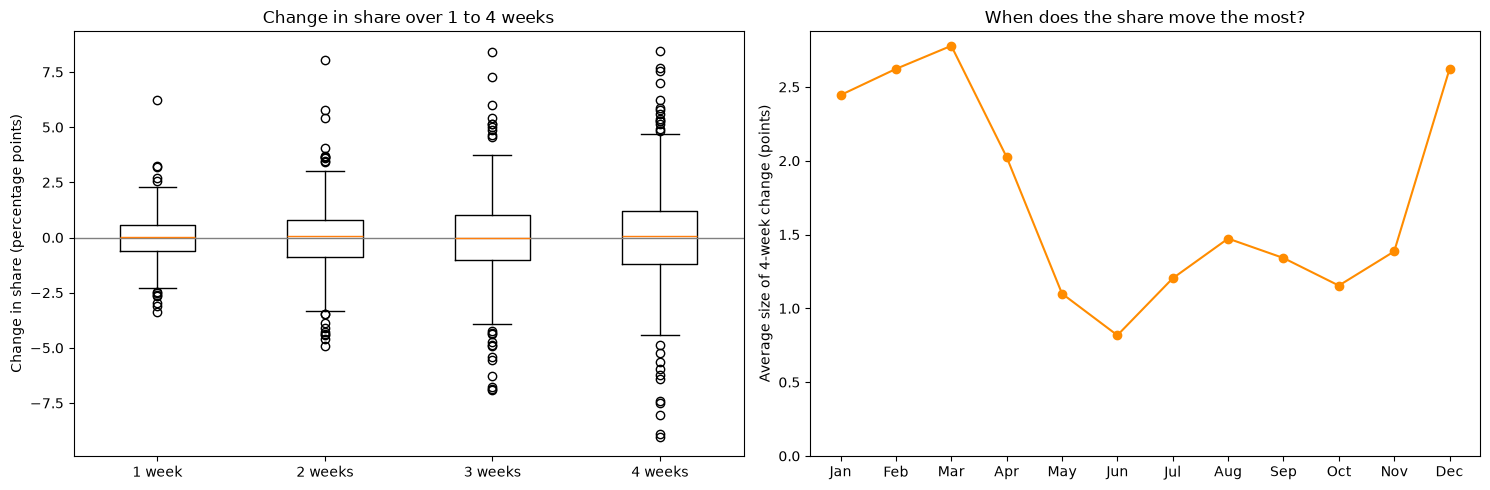

In [12]:
change_summary_rows = []
weekly_changes = {}
for weeks_ahead in [1, 2, 3, 4]:
    earlier_share = icu_weekly["icu_occupancy_share_pct"].shift(weeks_ahead)
    earlier_flag = icu_weekly["is_voluntary_reporting_week"].shift(weeks_ahead, fill_value=True)
    usable = ~icu_weekly["is_voluntary_reporting_week"] & ~earlier_flag
    change = (icu_weekly["icu_occupancy_share_pct"] - earlier_share)[usable].dropna()
    weekly_changes[weeks_ahead] = change
    change_summary_rows.append({
        "weeks_ahead": weeks_ahead,
        "comparisons": len(change),
        "avg_size_of_change": change.abs().mean(),
        "middle_80pct_low": change.quantile(0.10),
        "middle_80pct_high": change.quantile(0.90),
        "largest_rise": change.max(),
        "largest_drop": change.min(),
    })
change_summary = pd.DataFrame(change_summary_rows).set_index("weeks_ahead").round(2)
print("How much the share changes over 1 to 4 weeks (percentage points):")
print(change_summary.to_string())

figure, (spread_axis, season_axis) = plt.subplots(1, 2, figsize=(15, 5))
spread_axis.boxplot(
    [weekly_changes[weeks_ahead] for weeks_ahead in [1, 2, 3, 4]],
    tick_labels=["1 week", "2 weeks", "3 weeks", "4 weeks"],
    showfliers=True,
)
spread_axis.axhline(0, color="gray", linewidth=1)
spread_axis.set_ylabel("Change in share (percentage points)")
spread_axis.set_title("Change in share over 1 to 4 weeks")

four_week_change_by_month = (
    weekly_changes[4].abs().groupby(icu_weekly.loc[weekly_changes[4].index, "month"]).mean()
)
season_axis.plot(four_week_change_by_month.index, four_week_change_by_month.values, marker="o", color="darkorange")
season_axis.set_xticks(range(1, 13))
season_axis.set_xticklabels(month_labels)
season_axis.set_ylim(bottom=0)
season_axis.set_ylabel("Average size of 4-week change (points)")
season_axis.set_title("When does the share move the most?")
plt.tight_layout()
plt.show()

### Finding: "same as this week" is a strong baseline at 1 week, weaker at 4 weeks and in winter

**Result**
- A typical 1-week change in the share is 0.8 points, and 8 in 10 weekly changes fall between -1.3 and +1.3 points.
- A typical 4-week change is 1.8 points, with 8 in 10 falling between -2.7 and +2.6 points. Changes grow with the horizon, but more slowly than the number of weeks, because moves often partly reverse.
- The share moves most from December to March (a typical 4-week change of 2.4 to 2.8 points) and least in June (0.8 points), covering both the climb to the winter peak and the fall after it.
- All of the largest 4-week moves (up to 9 points) happened between late 2020 and early 2022. Since 2023, the typical 4-week change has been about 1.1 to 1.4 points.

**Interpretation**
The typical change is exactly how far off the "same as this week" rule would be. At 1 week, that is about 0.8 points, or roughly 80 patients on about 10,000 ICU beds, which leaves little room for a more complex model to improve on. At 4 weeks, the rule is off by about 180 patients, and it does worst in winter, when the share moves fastest. Models are therefore expected to add the most value at longer horizons and during winter. Matching the baseline at 1 week would be consistent with this data, not a sign of failure.

**Limitation**
These are averages over all years. Because 2021 and 2022 moved much more than recent years, the typical change in a future year may be closer to the post-2023 values than to the full-period averages.

## Question 4: What drives the winter rise?
The winter rise could come from patients with respiratory illnesses (COVID-19, flu, RSV), or from everyone else in the ICU, such as patients after surgery, heart attacks, or injuries. If respiratory patients explain most of the rise, tracking those illnesses should help the forecast. If not, they add little.

**Method:** split ICU beds in use into two groups: patients with a confirmed respiratory illness, and all other patients. Each is shown as a share of ICU beds available, so the two add up to the total share.

**Caveat on the data:** COVID-19 has been reported since August 2020, flu since October 2020, and RSV only since late 2023. Flu reporting rules also changed over time, so flu counts from before November 2024 may not be comparable with later ones. Only confirmed cases are counted, so the respiratory group is a minimum.

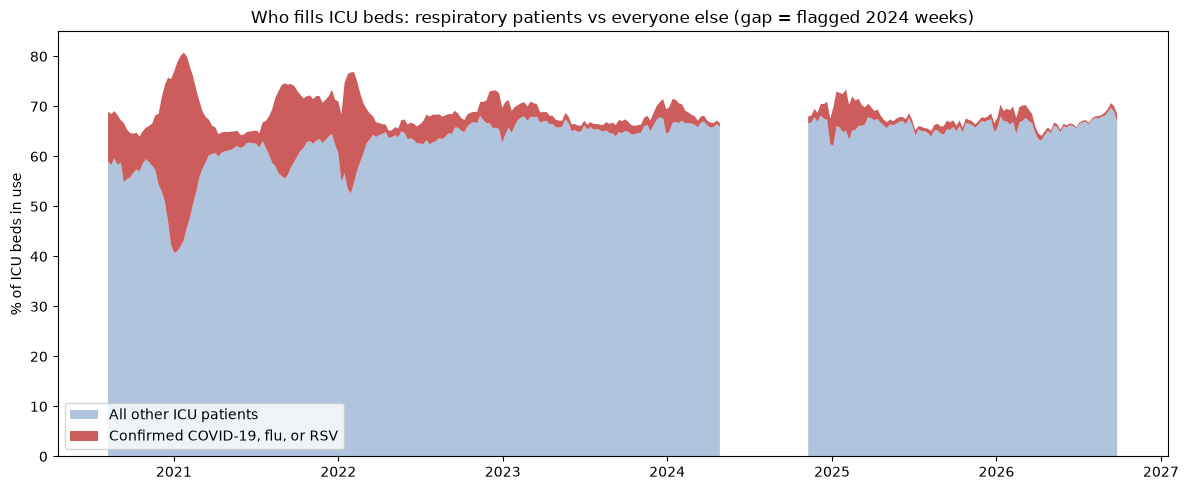

Winter (Dec to Feb) minus the following summer (Jun to Aug), in percentage points:
         total_rise  rise_from_respiratory  rise_from_other_patients  pct_of_rise_from_respiratory
winter                                                                                            
2020-21         8.7                   22.2                     -13.5                         255.6
2021-22         5.7                   10.0                      -4.4                         177.1
2022-23         4.6                    3.9                       0.7                          84.8
2024-25         4.8                    4.9                      -0.2                         103.5
2025-26         1.6                    1.9                      -0.3                         115.5


In [13]:
icu_weekly["respiratory_icu_patients"] = icu_weekly[
    ["covid_icu_patients", "flu_icu_patients", "rsv_icu_patients"]
].sum(axis=1, min_count=1)
icu_weekly["respiratory_share_pct"] = icu_weekly["respiratory_icu_patients"] / icu_weekly["icu_beds_available"] * 100
icu_weekly["other_patients_share_pct"] = icu_weekly["icu_occupancy_share_pct"] - icu_weekly["respiratory_share_pct"]
reliable_weeks = icu_weekly[~icu_weekly["is_voluntary_reporting_week"]]

figure, split_axis = plt.subplots(figsize=(12, 5))
# Flagged weeks are set to blank (not removed) so the chart shows a gap instead of
# drawing a straight line across them
chart_weeks = icu_weekly.copy()
chart_weeks.loc[chart_weeks["is_voluntary_reporting_week"], ["other_patients_share_pct", "respiratory_share_pct"]] = np.nan
split_axis.stackplot(
    chart_weeks["week_ending"],
    chart_weeks["other_patients_share_pct"],
    chart_weeks["respiratory_share_pct"],
    labels=["All other ICU patients", "Confirmed COVID-19, flu, or RSV"],
    colors=["lightsteelblue", "indianred"],
)
split_axis.set_ylim(0, 85)
split_axis.set_ylabel("% of ICU beds in use")
split_axis.set_title("Who fills ICU beds: respiratory patients vs everyone else (gap = flagged 2024 weeks)")
split_axis.legend(loc="lower left")
plt.tight_layout()
plt.show()

winter_months = [12, 1, 2]
summer_months = [6, 7, 8]
season_comparison_rows = []
for winter_start_year in range(2020, 2026):
    winter = reliable_weeks[
        ((reliable_weeks["year"] == winter_start_year) & (reliable_weeks["month"] == 12))
        | ((reliable_weeks["year"] == winter_start_year + 1) & reliable_weeks["month"].isin([1, 2]))
    ]
    summer = reliable_weeks[(reliable_weeks["year"] == winter_start_year + 1) & reliable_weeks["month"].isin(summer_months)]
    if len(winter) < 10 or len(summer) < 10:
        continue
    season_comparison_rows.append({
        "winter": f"{winter_start_year}-{str(winter_start_year + 1)[-2:]}",
        "total_rise": winter["icu_occupancy_share_pct"].mean() - summer["icu_occupancy_share_pct"].mean(),
        "rise_from_respiratory": winter["respiratory_share_pct"].mean() - summer["respiratory_share_pct"].mean(),
        "rise_from_other_patients": winter["other_patients_share_pct"].mean() - summer["other_patients_share_pct"].mean(),
    })
season_comparison = pd.DataFrame(season_comparison_rows).set_index("winter")
season_comparison["pct_of_rise_from_respiratory"] = (
    season_comparison["rise_from_respiratory"] / season_comparison["total_rise"] * 100
)
print("Winter (Dec to Feb) minus the following summer (Jun to Aug), in percentage points:")
print(season_comparison.round(1).to_string())

### Finding: in recent winters, respiratory patients account for nearly all of the winter rise

**Result**
- The share of ICU beds holding confirmed COVID-19, flu, or RSV patients was far larger in 2020 to 2022 than in any later year. It still rises each winter, but on a much smaller scale.
- In winter 2020-21, the respiratory share rose by about 22 points compared with the following summer, while the total share rose by only about 9. The share held by all other patients fell by about 13.5 points.
- In 2022-23, respiratory patients accounted for about 3.9 of the 4.6-point winter rise (about 85%). In 2024-25 (4.9 of 4.8) and 2025-26 (1.9 of 1.6), they accounted for the entire rise, while other patients stayed about flat.

**Interpretation**
In recent years, the winter rise in ICU use comes almost entirely from respiratory illness. Patients with other conditions fill a fairly steady share of beds year-round. This suggests that tracking COVID-19, flu, and RSV could help forecast the winter rise. During the large 2020-21 surge, other patients' share fell as respiratory patients rose, which is consistent with hospitals postponing non-urgent surgeries to make room. Because hospitals free up space this way, the total share rises less than respiratory patients alone would suggest.

**Limitation**
Only confirmed cases are counted, so the respiratory share is a minimum. RSV has only been reported since late 2023, and flu reporting rules changed over time, so respiratory counts from earlier years may not be fully comparable with recent ones. The 2025-26 rise was small (1.6 points), so its percentage is sensitive to small changes. The data shows that other patients' share fell in 2020-21, but not why. Winter 2023-24 is missing from the table because the following summer falls in the flagged reporting period.

## Question 5: Do hospital admissions rise before ICU occupancy?
New hospital admissions count patients arriving each week. ICU occupancy counts patients already in beds. Patients who get sicker after admission may move to the ICU days later, so admissions could rise first. If they consistently lead, they could warn planners before the ICU fills up.

**Method:** compare weekly respiratory admissions (COVID-19, flu, and RSV combined) with the share of ICU beds in use, shifting admissions 0 to 6 weeks earlier. The correlation (a score from -1 to 1 of how closely two series move together) is measured at each shift. If it peaks at a shift above zero, admissions lead the ICU by that many weeks.

To avoid mixing in the long-term level and the 2024 flags, this uses November 2024 onward, the period when all three illnesses were reported under the same rules. That is about 100 weeks, covering two winters.

Weeks compared: 99 (2024-11-09 to 2026-09-26)
                          correlation_of_levels  correlation_of_weekly_changes
admissions_weeks_earlier                                                      
0                                          0.71                          -0.03
1                                          0.73                           0.03
2                                          0.74                           0.33
3                                          0.71                           0.11
4                                          0.66                           0.26
5                                          0.59                           0.03
6                                          0.50                          -0.08


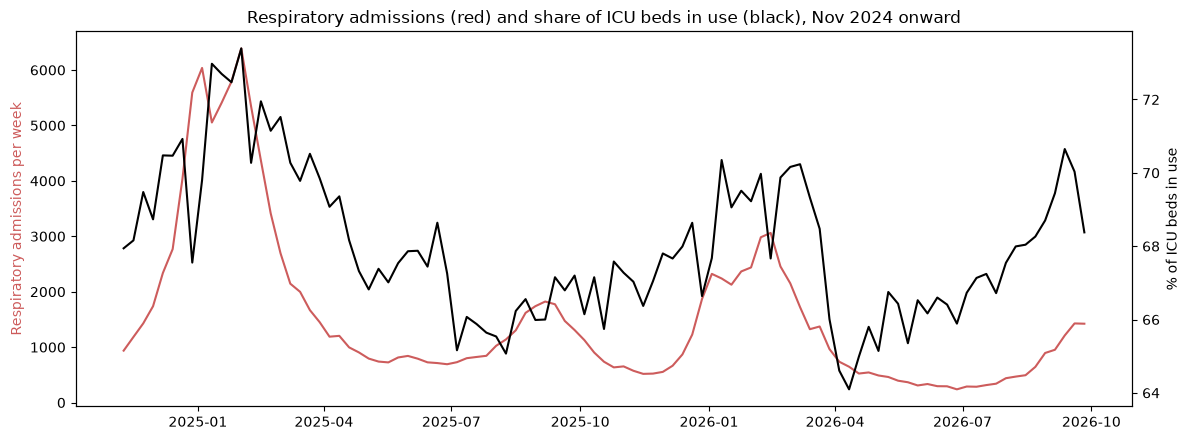

In [14]:
comparison_period = icu_weekly[icu_weekly["week_ending"] >= "2024-11-09"].copy()
comparison_period["respiratory_new_admissions"] = comparison_period[
    ["covid_new_admissions", "flu_new_admissions", "rsv_new_admissions"]
].sum(axis=1)

lead_rows = []
for weeks_earlier in range(0, 7):
    earlier_admissions = comparison_period["respiratory_new_admissions"].shift(weeks_earlier)
    correlation = comparison_period["icu_occupancy_share_pct"].corr(earlier_admissions)
    change_correlation = comparison_period["icu_occupancy_share_pct"].diff().corr(earlier_admissions.diff())
    lead_rows.append({
        "admissions_weeks_earlier": weeks_earlier,
        "correlation_of_levels": correlation,
        "correlation_of_weekly_changes": change_correlation,
    })
lead_summary = pd.DataFrame(lead_rows).set_index("admissions_weeks_earlier").round(2)
print(f"Weeks compared: {len(comparison_period)} ({comparison_period['week_ending'].min().date()} to {comparison_period['week_ending'].max().date()})")
print(lead_summary.to_string())

figure, admissions_axis = plt.subplots(figsize=(12, 4.5))
admissions_axis.plot(comparison_period["week_ending"], comparison_period["respiratory_new_admissions"], color="indianred")
admissions_axis.set_ylabel("Respiratory admissions per week", color="indianred")
share_axis = admissions_axis.twinx()
share_axis.plot(comparison_period["week_ending"], comparison_period["icu_occupancy_share_pct"], color="black")
share_axis.set_ylabel("% of ICU beds in use", color="black")
admissions_axis.set_title("Respiratory admissions (red) and share of ICU beds in use (black), Nov 2024 onward")
plt.tight_layout()
plt.show()

### Finding: admissions may lead ICU use by about 2 weeks, but the evidence is weak

**Result**
- Comparing levels, respiratory admissions and the share of ICU beds in use are closely related at every shift from 0 to 3 weeks (correlation 0.71 to 0.74), with no clear peak.
- Comparing weekly changes, the relationship is much weaker. The highest correlation is 0.33, with admissions 2 weeks earlier, but neighboring shifts are close to zero (0.03 at 1 week, 0.11 at 3 weeks), and 4 weeks reaches 0.26.

**Interpretation**
The high correlation of levels mostly reflects that both series rise every winter, so it does not show that admissions predict ICU use. Weekly changes remove most of that shared seasonal pattern and are the stricter test. They show a modest link at 2 weeks, but not the smooth pattern across neighboring shifts that a real 2-week delay would be expected to produce. With about 100 weeks of data, correlations below roughly 0.2 can appear by chance, and testing seven different shifts raises the odds that one looks strong by accident.

**Decision**
Respiratory admissions from 2 weeks earlier will be tested as a model input. The forecast evaluation, not this correlation, will decide whether it is kept.

**Limitation**
This comparison covers only November 2024 onward (about 100 weeks and two winters), the period when COVID-19, flu, and RSV admissions were all reported under the same rules. Earlier years could not be included without mixing in reporting changes.

## Question 6: How stable is the number of ICU beds?
The plan is to forecast the share and convert it to beds by multiplying by the number of ICU beds available. That only works if the bed count is predictable. If it swings a lot, the conversion adds its own error.

**Method:** plot ICU beds available over time, and measure how much it changes week to week and over 4 weeks since November 2024, the current reporting period.

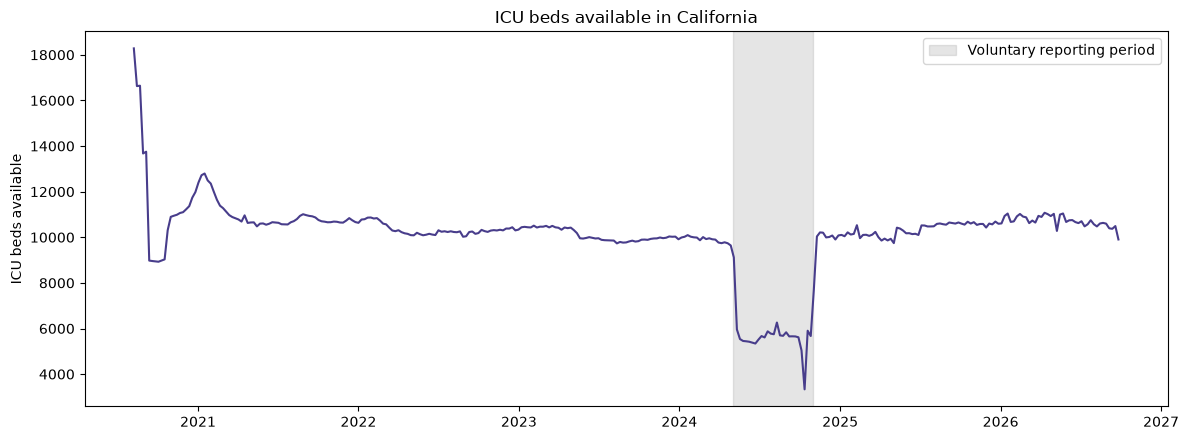

ICU beds available since November 2024:
  Average: 10,468   Lowest: 9,744   Highest: 11,074
  Typical 1-week change: 1.26%   Largest: 6.99%
  Typical 4-week change: 1.71%   Largest: 7.20%

Largest 1-week changes:
week_ending
2026-05-16    6.99
2025-05-10    6.95
2026-05-09   -6.81
2026-09-26   -5.60
2025-02-15   -5.39


In [15]:
figure, capacity_axis = plt.subplots(figsize=(12, 4.5))
capacity_axis.plot(icu_weekly["week_ending"], icu_weekly["icu_beds_available"], color="darkslateblue")
capacity_axis.axvspan(pd.Timestamp("2024-05-01"), pd.Timestamp("2024-10-31"), color="gray", alpha=0.2, label="Voluntary reporting period")
capacity_axis.set_ylabel("ICU beds available")
capacity_axis.set_title("ICU beds available in California")
capacity_axis.legend()
plt.tight_layout()
plt.show()

current_period_capacity = icu_weekly.loc[icu_weekly["week_ending"] >= "2024-11-09", ["week_ending", "icu_beds_available"]].set_index("week_ending")["icu_beds_available"]
one_week_change_pct = current_period_capacity.pct_change(1).dropna() * 100
four_week_change_pct = current_period_capacity.pct_change(4).dropna() * 100

print("ICU beds available since November 2024:")
print(f"  Average: {current_period_capacity.mean():,.0f}   Lowest: {current_period_capacity.min():,.0f}   Highest: {current_period_capacity.max():,.0f}")
print(f"  Typical 1-week change: {one_week_change_pct.abs().mean():.2f}%   Largest: {one_week_change_pct.abs().max():.2f}%")
print(f"  Typical 4-week change: {four_week_change_pct.abs().mean():.2f}%   Largest: {four_week_change_pct.abs().max():.2f}%")
print()
print("Largest 1-week changes:")
print(one_week_change_pct.reindex(one_week_change_pct.abs().sort_values(ascending=False).index).head(5).round(2).to_string())

### Finding: the bed count is stable except for reporting dips, and it expands during large surges

**Result**
- Since November 2024, ICU beds available averaged about 10,470, ranging from 9,744 to 11,074. The typical 1-week change is 1.3%, or about 130 beds.
- All five of the largest 1-week changes line up with dips in the share of hospitals reporting. For example, the week ending May 9, 2026 dropped about 750 beds as reporting fell from 94.5% to 90.5%, and the bed count returned the following week. The share of ICU beds in use stayed steady through each of these dips.
- From December 2020 to mid-January 2021, ICU beds available rose by about 1,570 (14%) while reporting stayed near 96%, then fell back by March. This happened during the highest ICU occupancy in the dataset.

**Interpretation**
Week-to-week movement in the bed count is mostly reporting noise, not real changes in capacity, which again supports forecasting the share rather than the count. Converting a forecast share into patients still carries this noise: at 70% occupancy, a 130-bed difference shifts the patient estimate by about 90, as large as the typical 1-week error of the "same as this week" rule. Using an average of recent weeks for the bed count, rather than the latest week alone, should reduce this.

The early 2021 rise in beds is consistent with hospitals opening extra ICU beds during the surge. Had capacity stayed at its December level, the January 2021 peak would have been about 91% instead of 80.7%. During a large surge, the share therefore understates how much pressure ICUs are under, so forecasts should be reported as both a share and a patient count.

**Limitation**
The data shows that capacity grew in early 2021 but not how hospitals added those beds. Reporting dips are identified from the hospital reporting column, which covers occupancy reporting and may not match capacity reporting exactly.

## Summary: what the models must handle

| # | Finding | What the models must do |
|---|---|---|
| 1 | The share rises about 7 points every winter (73.5% in January vs about 66.5% in early summer). | Know the time of year, or every winter rise will be missed. |
| 2 | The size and timing of the winter peak change from year to year (peaks from 71.5% to 80.7%, from late December to early February). | Respond to recent weeks, not just repeat last year's calendar. |
| 3 | The level has stayed near 68% since 2023, but 2021 and 2022 swung much more than recent years. | Be trained both with and without 2021 and 2022, and compared on recent weeks. |
| 4 | The share usually moves less than 1 point in a week, but about 1.8 points over 4 weeks, and the most from December to March. | Be judged separately at each horizon and season. Beating "same as this week" at 1 week will be hard; the most room to improve is at 3 to 4 weeks and in winter. |
| 5 | In recent winters, confirmed COVID-19, flu, and RSV patients account for nearly all of the winter rise. | Test respiratory illness data as an input. |
| 6 | Respiratory admissions show a weak, inconsistent link to ICU changes 2 weeks later. | Test admissions as an input, and keep it only if forecasts improve. |
| 7 | Week-to-week changes in the bed count are mostly reporting noise, and capacity expanded during the 2021 surge. | Convert forecasts to patients using an average of recent weeks' bed counts, and report both the share and the patient count. |

## Data handling carried into modeling
- The 27 flagged 2024 voluntary reporting weeks are not used to score forecasts, since their values run about 2 points low.
- The most recent week in the file is likely undercounted (Notebook 01), so forecasts starting from it should be treated with caution until the data is refreshed.

## Baselines every model must beat
1. **Same as this week:** the share stays where it is now.
2. **Same as last year:** the share matches the same week one year earlier. This captures the yearly pattern but ignores recent weeks.

A model that cannot beat both at a given horizon is not adding value there.

## Overall
The share of ICU beds in use is a stable, strongly seasonal series. Its winter rise is driven mostly by respiratory illness, and its largest risks come from surges bigger than anything since 2022. The forecasting challenge is less about the typical week, which is easy to predict, and more about the timing and size of each winter peak, which is where planners need the warning most.